## Market Basket Analysis – Exploratory Approach

This notebook explores association rule mining using the Groceries dataset.
Multiple configurations of support, confidence, and lift were tested to
understand how parameter choices affect rule quality, stability, and interpretability.

The objective is not to find a single “correct” model, but to evaluate
trade-offs between rule coverage and stength.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

In [2]:
df = pd.read_csv("Groceries_dataset.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38765 entries, 0 to 38764
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Member_number    38765 non-null  int64 
 1   Date             38765 non-null  object
 2   itemDescription  38765 non-null  object
dtypes: int64(1), object(2)
memory usage: 908.7+ KB


In [4]:
unique_item_descriptions = df['itemDescription'].nunique()
print(f'The number of unique itemDescription values is: {unique_item_descriptions}')

The number of unique itemDescription values is: 167


In [5]:
unique_memberNumber = df['Member_number'].nunique()
print(f'The number of unique Member_number is: {unique_memberNumber}')

The number of unique Member_number is: 3898


In [6]:
df.head(10)

,Member_number,Date,itemDescription
0,1808,21-07-2015,tropical fruit
1,2552,05-01-2015,whole milk
2,2300,19-09-2015,pip fruit
3,1187,12-12-2015,other vegetables
4,3037,01-02-2015,whole milk
5,4941,14-02-2015,rolls/buns
6,4501,08-05-2015,other vegetables
7,3803,23-12-2015,pot plants
8,2762,20-03-2015,whole milk
9,4119,12-02-2015,tropical fruit


In [7]:
# Calculate the frequency of each item_description
item_frequencies = df['itemDescription'].value_counts().head(10)

# Display the 10 most frequent item descriptions
print(item_frequencies)

whole milk          2502
other vegetables    1898
rolls/buns          1716
soda                1514
yogurt              1334
root vegetables     1071
tropical fruit      1032
bottled water        933
sausage              924
citrus fruit         812
Name: itemDescription, dtype: int64


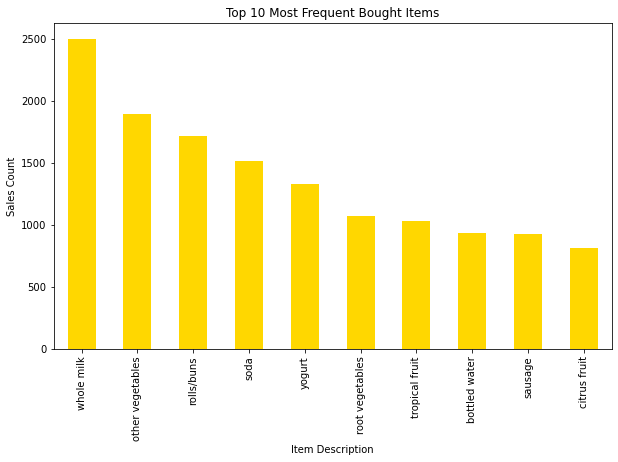

In [8]:
# Bar chart of Item Description
plt.figure(figsize=(10, 6))
item_frequencies.plot(kind='bar', color='#FFD700')
plt.title('Top 10 Most Frequent Bought Items')
plt.xlabel('Item Description')
plt.ylabel('Sales Count')
plt.show()


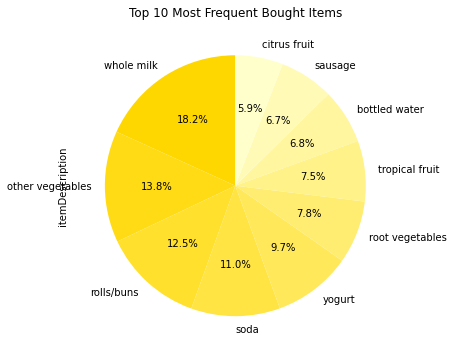

In [9]:
# Distribution of Item Description
cmap = LinearSegmentedColormap.from_list('custom', ['#FFD700','#FFFFCC'])

plt.figure(figsize=(10, 6))
item_frequencies.plot(kind='pie', autopct='%1.1f%%', startangle=90, cmap=cmap)
plt.title('Top 10 Most Frequent Bought Items')
plt.show()

In [10]:
# Calculate the frequency of each Member Number
member_frequencies = df['Member_number'].value_counts().head(10)

# Display the 10 most frequent member_numbers
print(member_frequencies)

3180    36
3737    33
3050    33
2051    33
2625    31
3915    31
2433    31
2271    31
3872    30
3289    29
Name: Member_number, dtype: int64


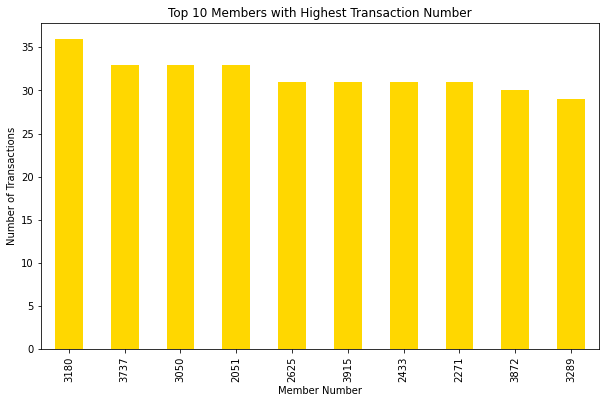

In [11]:
# Bar chart of Member Number
plt.figure(figsize=(10, 6))
member_frequencies.plot(kind='bar', color='#FFD700')
plt.title('Top 10 Members with Highest Transaction Number')
plt.xlabel('Member Number')
plt.ylabel('Number of Transactions')
plt.show()

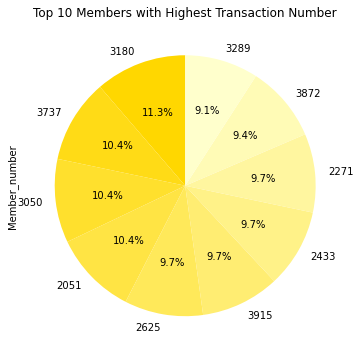

In [12]:
# Distribution of Member Number
cmap = LinearSegmentedColormap.from_list('custom', ['#FFD700','#FFFFCC'])

plt.figure(figsize=(10, 6))
member_frequencies.plot(kind='pie', autopct='%1.1f%%', startangle=90, cmap=cmap)
plt.title('Top 10 Members with Highest Transaction Number')
plt.show()

In [13]:
#Most Number of Transactions

# Calculate the frequency of each date in the dataset
date_frequencies = df['Date'].value_counts().head(15)

# Display the top 10 most frequent dates
print(date_frequencies)

21-01-2015    96
21-07-2015    93
29-11-2015    92
08-08-2015    92
30-04-2015    91
28-08-2014    88
26-03-2015    88
30-09-2015    87
19-06-2015    85
16-05-2015    85
09-11-2015    83
01-04-2015    83
20-08-2015    83
21-08-2015    83
27-11-2015    82
Name: Date, dtype: int64


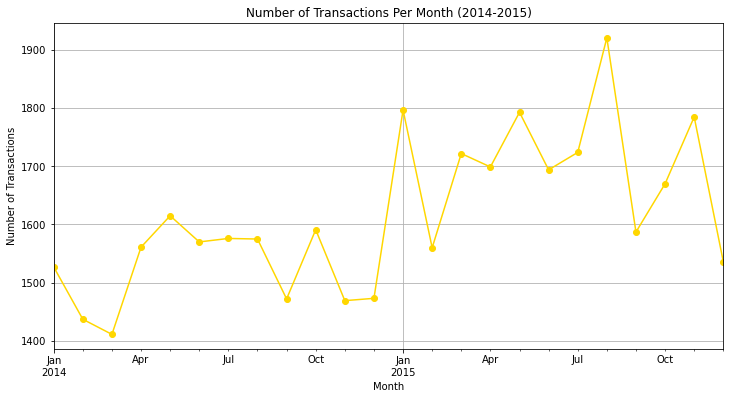

In [14]:
# Line Chart to show the number of transactions per month in Jan 2014 to Dec 2015
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')

# Group the data by month
monthly_transactions = df.groupby(df['Date'].dt.to_period('M')).size()

monthly_transactions.index = monthly_transactions.index.to_timestamp()

# Plot the line chart
plt.figure(figsize=(12, 6))
monthly_transactions.plot(kind='line', marker='o', color ='#FFD700')
plt.title('Number of Transactions Per Month (2014-2015)')
plt.xlabel('Month')
plt.ylabel('Number of Transactions')
plt.grid(True)
plt.show()

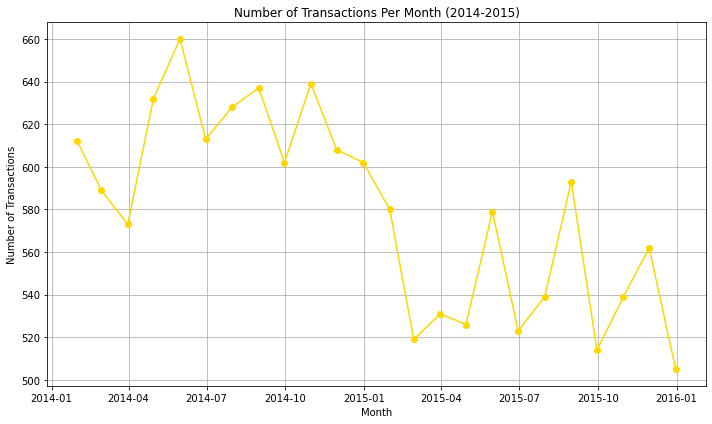

In [15]:
# Line Chart to show the number of transactions per month in Jan 2014 to Dec 2015 (unique values for member_number)
df['date'] = pd.to_datetime(df['Date'])

# Group by 'Date' 
monthly_transactions = df.resample('M', on='Date')['Member_number'].nunique()

plt.figure(figsize=(10, 6))
plt.plot(monthly_transactions.index, monthly_transactions.values, marker='o', color ='#FFD700')
plt.xlabel('Month')
plt.ylabel('Number of Transactions')
plt.title('Number of Transactions Per Month (2014-2015)')
plt.grid(True)
plt.tight_layout()
plt.show()

In [16]:
transactions = df.groupby(['Member_number', 'Date'])
transactions.count()

itemDescription  date
Member_number Date                             
1000          2014-06-24                3     3
              2015-03-15                4     4
              2015-05-27                2     2
              2015-07-24                2     2
              2015-11-25                2     2
...                                   ...   ...
4999          2015-05-16                2     2
              2015-12-26                2     2
5000          2014-03-09                2     2
              2014-11-16                2     2
              2015-02-10                3     3

[14963 rows x 2 columns]

In [17]:
list_transactions = [i[1]['itemDescription'].tolist() for i in list(transactions)]
list_transactions[:20]

[['whole milk', 'pastry', 'salty snack'],
 ['sausage', 'whole milk', 'semi-finished bread', 'yogurt'],
 ['soda', 'pickled vegetables'],
 ['canned beer', 'misc. beverages'],
 ['sausage', 'hygiene articles'],
 ['sausage', 'whole milk', 'rolls/buns'],
 ['whole milk', 'soda'],
 ['frankfurter', 'soda', 'whipped/sour cream'],
 ['beef', 'white bread'],
 ['frankfurter', 'curd'],
 ['frozen vegetables', 'other vegetables'],
 ['butter', 'whole milk'],
 ['tropical fruit', 'sugar'],
 ['butter milk', 'specialty chocolate'],
 ['frozen meals', 'dental care'],
 ['rolls/buns', 'rolls/buns'],
 ['root vegetables', 'detergent'],
 ['sausage', 'rolls/buns'],
 ['pip fruit', 'whole milk', 'tropical fruit'],
 ['dish cleaner', 'cling film/bags']]

In [18]:
from apyori import apriori

In [19]:
#Possible Range
#min_support = 0.001 to 0.005
#min_confidence = 0.05 to 0.2
#min_lift = 1.2 to 3
rules = apriori(list_transactions, min_support=0.001, min_confidence=0.05, min_lift=1.2, min_length=2, max_length=2)

In [20]:
results = list(rules)

In [21]:
def inspect(results):
    lhs = [tuple(result[2][0][0])[0] for result in results]
    rhs = [tuple(result[2][0][1])[0] for result in results]
    support = [result[1]*100 for result in results]
    confidence = [result[2][0][2]*100 for result in results]
    lift = [result[2][0][3] for result in results]
    return list(zip(lhs,rhs,support,confidence,lift))
final_result = pd.DataFrame(inspect(results), columns=['Product 1','Product 2','Support(%)','Confidence(%)','lift'])
final_result['Rule'] = final_result['Product 1'] + '->' + final_result['Product 2']

In [22]:
final_result

,Product 1,Product 2,Support(%),Confidence(%),lift,Rule
0,beverages,sausage,0.153712,9.274194,1.536764,beverages->sausage
1,bottled beer,sausage,0.334158,7.374631,1.222000,bottled beer->sausage
2,sugar,bottled water,0.147029,8.301887,1.368074,sugar->bottled water
3,brown bread,canned beer,0.240593,6.394316,1.362937,brown bread->canned beer
4,candy,citrus fruit,0.100247,6.976744,1.313120,candy->citrus fruit
5,white bread,canned beer,0.153712,6.406685,1.365573,white bread->canned beer
6,cat food,tropical fruit,0.100247,8.474576,1.250543,cat food->tropical fruit
7,chewing gum,yogurt,0.140346,11.666667,1.358508,chewing gum->yogurt
8,specialty chocolate,citrus fruit,0.140346,8.786611,1.653762,specialty chocolate->citrus fruit
9,curd,sausage,0.294059,8.730159,1.446615,curd->sausage


# Experiment Parameters

# Changing max_length

In [23]:
# max_length = 3
rules = apriori(list_transactions, min_support=0.001, min_confidence=0.05, min_lift=1.2, min_length=2, max_length=3)
results = list(rules)

In [24]:
def inspect(results):
    lhs = [tuple(result[2][0][0]) for result in results]
    rhs = [tuple(result[2][0][1]) for result in results]
    support = [result[1]*100 for result in results]
    confidence = [result[2][0][2]*100 for result in results]
    lift = [result[2][0][3] for result in results]
    
    return [(item[0] if len(item) > 0 else None,
             item[1] if len(item) > 1 else None,
             next_item[0] if len(next_item) > 0 else None,
             sup, conf, lif) 
            for item, next_item, sup, conf, lif in zip(lhs, rhs, support, confidence, lift)]

final_result = pd.DataFrame(inspect(results), columns=['Product 1', 'Product 2', 'Product 3', 'Support(%)', 'Confidence(%)', 'Lift'])

final_result['Rule'] = final_result.apply(lambda row: f"{row['Product 1'] if row['Product 1'] else ''} & {row['Product 2'] if row['Product 2'] else ''} -> {row['Product 3'] if row['Product 3'] else ''}", axis=1)
print(final_result)

                    Product 1   Product 2           Product 3  Support(%)  \
0                   beverages        None             sausage    0.153712   
1                bottled beer        None             sausage    0.334158   
2                       sugar        None       bottled water    0.147029   
3                 brown bread        None         canned beer    0.240593   
4                       candy        None        citrus fruit    0.100247   
5                 white bread        None         canned beer    0.153712   
6                    cat food        None      tropical fruit    0.100247   
7                 chewing gum        None              yogurt    0.140346   
8         specialty chocolate        None        citrus fruit    0.140346   
9                        curd        None             sausage    0.294059   
10                  detergent        None              yogurt    0.106930   
11                      flour        None      tropical fruit    0.106930   

In [25]:
#max_length = 4

rules = apriori(list_transactions, min_support=0.001, min_confidence=0.05, min_lift=1.2, min_length=2, max_length=4)
results = list(rules)

In [26]:
def inspect(results):
    records = []
    for result in results:
        for ordered_statistic in result.ordered_statistics:
            lhs_items = tuple(ordered_statistic.items_base)
            rhs_items = tuple(ordered_statistic.items_add)
            support = result.support
            confidence = ordered_statistic.confidence
            lift = ordered_statistic.lift
            
           
            items = lhs_items + rhs_items + (None,) * (4 - len(lhs_items) - len(rhs_items))
            
            records.append((*items, support*100, confidence*100, lift))
    return records

final_result = pd.DataFrame(inspect(results), columns=['Product 1', 'Product 2', 'Product 3', 'Product 4', 'Support(%)', 'Confidence(%)', 'Lift'])

final_result['Rule'] = final_result.apply(lambda row: 
    f"{row['Product 1'] if row['Product 1'] else ''} & "
    f"{row['Product 2'] if row['Product 2'] else ''} & "
    f"{row['Product 3'] if row['Product 3'] else ''} -> "
    f"{row['Product 4'] if row['Product 4'] else ''}".strip(" & "), axis=1
)

print(final_result)

                    Product 1           Product 2   Product 3 Product 4  \
0                   beverages             sausage        None      None   
1                bottled beer             sausage        None      None   
2                     sausage        bottled beer        None      None   
3                       sugar       bottled water        None      None   
4                 brown bread         canned beer        None      None   
5                 canned beer         brown bread        None      None   
6                       candy        citrus fruit        None      None   
7                 white bread         canned beer        None      None   
8                    cat food      tropical fruit        None      None   
9                 chewing gum              yogurt        None      None   
10        specialty chocolate        citrus fruit        None      None   
11                       curd             sausage        None      None   
12                  deter

In [27]:
#max_length = 5 -> NO CHANGES with Max_length = 4

rules = apriori(list_transactions, min_support=0.001, min_confidence=0.05, min_lift=1.2, min_length=2, max_length=5)
results = list(rules)

In [28]:
def inspect(results):
    records = []
    for result in results:
        for ordered_statistic in result.ordered_statistics:
           
            lhs_items = tuple(ordered_statistic.items_base)
            rhs_items = tuple(ordered_statistic.items_add)
            support = result.support
            confidence = ordered_statistic.confidence
            lift = ordered_statistic.lift
            
            items = lhs_items + rhs_items + (None,) * (5 - len(lhs_items) - len(rhs_items))
            
            records.append((*items, support*100, confidence*100, lift))
    return records

final_result = pd.DataFrame(inspect(results), columns=['Product 1', 'Product 2', 'Product 3', 'Product 4', 'Product 5', 'Support(%)', 'Confidence(%)', 'Lift'])

final_result['Rule'] = final_result.apply(lambda row: 
    f"{row['Product 1'] if row['Product 1'] else ''} & "
    f"{row['Product 2'] if row['Product 2'] else ''} & "
    f"{row['Product 3'] if row['Product 3'] else ''} & "
    f"{row['Product 4'] if row['Product 4'] else ''} -> "
    f"{row['Product 5'] if row['Product 5'] else ''}".strip(" & "), axis=1
)

print(final_result)


                    Product 1           Product 2   Product 3 Product 4  \
0                   beverages             sausage        None      None   
1                bottled beer             sausage        None      None   
2                     sausage        bottled beer        None      None   
3                       sugar       bottled water        None      None   
4                 brown bread         canned beer        None      None   
5                 canned beer         brown bread        None      None   
6                       candy        citrus fruit        None      None   
7                 white bread         canned beer        None      None   
8                    cat food      tropical fruit        None      None   
9                 chewing gum              yogurt        None      None   
10        specialty chocolate        citrus fruit        None      None   
11                       curd             sausage        None      None   
12                  deter

# min_support (max_length = 2)

In [29]:
#min_support = 0.001 to 0.005
#min_confidence = 0.05 to 0.2
#min_lift = 1.2 to 3
#min_support = 0.002
rules = apriori(list_transactions, min_support=0.002, min_confidence=0.05, min_lift=1.2, min_length=2, max_length=2)
results = list(rules)

def inspect(results):
    lhs = [tuple(result[2][0][0])[0] for result in results]
    rhs = [tuple(result[2][0][1])[0] for result in results]
    support = [result[1]*100 for result in results]
    confidence = [result[2][0][2]*100 for result in results]
    lift = [result[2][0][3] for result in results]
    return list(zip(lhs,rhs,support,confidence,lift))
final_result = pd.DataFrame(inspect(results), columns=['Product 1','Product 2','Support(%)','Confidence(%)','lift'])
final_result['Rule'] = final_result['Product 1'] + '->' + final_result['Product 2']

final_result

,Product 1,Product 2,Support(%),Confidence(%),lift,Rule
0,bottled beer,sausage,0.334158,7.374631,1.222000,bottled beer->sausage
1,brown bread,canned beer,0.240593,6.394316,1.362937,brown bread->canned beer
2,curd,sausage,0.294059,8.730159,1.446615,curd->sausage
3,frozen vegetables,sausage,0.207178,7.398568,1.225966,frozen vegetables->sausage


In [30]:
#min_support = 0.003
rules = apriori(list_transactions, min_support=0.003, min_confidence=0.05, min_lift=1.2, min_length=2, max_length=2)
results = list(rules)

def inspect(results):
    lhs = [tuple(result[2][0][0])[0] for result in results]
    rhs = [tuple(result[2][0][1])[0] for result in results]
    support = [result[1]*100 for result in results]
    confidence = [result[2][0][2]*100 for result in results]
    lift = [result[2][0][3] for result in results]
    return list(zip(lhs,rhs,support,confidence,lift))
final_result = pd.DataFrame(inspect(results), columns=['Product 1','Product 2','Support(%)','Confidence(%)','lift'])
final_result['Rule'] = final_result['Product 1'] + '->' + final_result['Product 2']

final_result

,Product 1,Product 2,Support(%),Confidence(%),lift,Rule
0,bottled beer,sausage,0.334158,7.374631,1.222,bottled beer->sausage


In [31]:
#min_support = 0.004
rules = apriori(list_transactions, min_support=0.004, min_confidence=0.05, min_lift=1.2, min_length=2, max_length=2)
results = list(rules)

def inspect(results):
    lhs = [tuple(result[2][0][0])[0] for result in results]
    rhs = [tuple(result[2][0][1])[0] for result in results]
    support = [result[1]*100 for result in results]
    confidence = [result[2][0][2]*100 for result in results]
    lift = [result[2][0][3] for result in results]
    return list(zip(lhs,rhs,support,confidence,lift))
final_result = pd.DataFrame(inspect(results), columns=['Product 1','Product 2','Support(%)','Confidence(%)','lift'])
final_result['Rule'] = final_result['Product 1'] + '->' + final_result['Product 2']

final_result

,Product 1,Product 2,Support(%),Confidence(%),lift,Rule


# # min_support (max_length = 3)

In [32]:
#min_support = 0.002
rules = apriori(list_transactions, min_support=0.002, min_confidence=0.05, min_lift=1.2, min_length=2, max_length=3)
results = list(rules)

def inspect(results):
    lhs = [tuple(result[2][0][0]) for result in results]
    rhs = [tuple(result[2][0][1]) for result in results]
    support = [result[1]*100 for result in results]
    confidence = [result[2][0][2]*100 for result in results]
    lift = [result[2][0][3] for result in results]
    
    return [(item[0] if len(item) > 0 else None,
             item[1] if len(item) > 1 else None,
             next_item[0] if len(next_item) > 0 else None,
             sup, conf, lif) 
            for item, next_item, sup, conf, lif in zip(lhs, rhs, support, confidence, lift)]

final_result = pd.DataFrame(inspect(results), columns=['Product 1', 'Product 2', 'Product 3', 'Support(%)', 'Confidence(%)', 'Lift'])
final_result['Rule'] = final_result.apply(lambda row: f"{row['Product 1'] if row['Product 1'] else ''} & {row['Product 2'] if row['Product 2'] else ''} -> {row['Product 3'] if row['Product 3'] else ''}", axis=1)

print(final_result)

           Product 1 Product 2    Product 3  Support(%)  Confidence(%)  \
0       bottled beer      None      sausage    0.334158       7.374631   
1        brown bread      None  canned beer    0.240593       6.394316   
2               curd      None      sausage    0.294059       8.730159   
3  frozen vegetables      None      sausage    0.207178       7.398568   

       Lift                             Rule  
0  1.222000       bottled beer &  -> sausage  
1  1.362937    brown bread &  -> canned beer  
2  1.446615               curd &  -> sausage  
3  1.225966  frozen vegetables &  -> sausage  


# min_confidence (max_length=2)

In [33]:
#min_confidence = 0.06
rules = apriori(list_transactions, min_support=0.001, min_confidence=0.06, min_lift=1.2, min_length=2, max_length=2)
results = list(rules)

def inspect(results):
    lhs = [tuple(result[2][0][0])[0] for result in results]
    rhs = [tuple(result[2][0][1])[0] for result in results]
    support = [result[1]*100 for result in results]
    confidence = [result[2][0][2]*100 for result in results]
    lift = [result[2][0][3] for result in results]
    return list(zip(lhs,rhs,support,confidence,lift))
final_result = pd.DataFrame(inspect(results), columns=['Product 1','Product 2','Support(%)','Confidence(%)','lift'])
final_result['Rule'] = final_result['Product 1'] + '->' + final_result['Product 2']

final_result

,Product 1,Product 2,Support(%),Confidence(%),lift,Rule
0,beverages,sausage,0.153712,9.274194,1.536764,beverages->sausage
1,bottled beer,sausage,0.334158,7.374631,1.222000,bottled beer->sausage
2,sugar,bottled water,0.147029,8.301887,1.368074,sugar->bottled water
3,brown bread,canned beer,0.240593,6.394316,1.362937,brown bread->canned beer
4,candy,citrus fruit,0.100247,6.976744,1.313120,candy->citrus fruit
5,white bread,canned beer,0.153712,6.406685,1.365573,white bread->canned beer
6,cat food,tropical fruit,0.100247,8.474576,1.250543,cat food->tropical fruit
7,chewing gum,yogurt,0.140346,11.666667,1.358508,chewing gum->yogurt
8,specialty chocolate,citrus fruit,0.140346,8.786611,1.653762,specialty chocolate->citrus fruit
9,curd,sausage,0.294059,8.730159,1.446615,curd->sausage


In [34]:
#min_confidence = 0.07
rules = apriori(list_transactions, min_support=0.001, min_confidence=0.07, min_lift=1.2, min_length=2, max_length=2)
results = list(rules)

def inspect(results):
    lhs = [tuple(result[2][0][0])[0] for result in results]
    rhs = [tuple(result[2][0][1])[0] for result in results]
    support = [result[1]*100 for result in results]
    confidence = [result[2][0][2]*100 for result in results]
    lift = [result[2][0][3] for result in results]
    return list(zip(lhs,rhs,support,confidence,lift))
final_result = pd.DataFrame(inspect(results), columns=['Product 1','Product 2','Support(%)','Confidence(%)','lift'])
final_result['Rule'] = final_result['Product 1'] + '->' + final_result['Product 2']

final_result

,Product 1,Product 2,Support(%),Confidence(%),lift,Rule
0,beverages,sausage,0.153712,9.274194,1.536764,beverages->sausage
1,bottled beer,sausage,0.334158,7.374631,1.222000,bottled beer->sausage
2,sugar,bottled water,0.147029,8.301887,1.368074,sugar->bottled water
3,cat food,tropical fruit,0.100247,8.474576,1.250543,cat food->tropical fruit
4,chewing gum,yogurt,0.140346,11.666667,1.358508,chewing gum->yogurt
5,specialty chocolate,citrus fruit,0.140346,8.786611,1.653762,specialty chocolate->citrus fruit
6,curd,sausage,0.294059,8.730159,1.446615,curd->sausage
7,detergent,yogurt,0.106930,12.403101,1.444261,detergent->yogurt
8,flour,tropical fruit,0.106930,10.958904,1.617141,flour->tropical fruit
9,frozen meals,sausage,0.126980,7.569721,1.254327,frozen meals->sausage


In [35]:
#min_confidence = 0.08
rules = apriori(list_transactions, min_support=0.001, min_confidence=0.08, min_lift=1.2, min_length=2, max_length=2)
results = list(rules)

def inspect(results):
    lhs = [tuple(result[2][0][0])[0] for result in results]
    rhs = [tuple(result[2][0][1])[0] for result in results]
    support = [result[1]*100 for result in results]
    confidence = [result[2][0][2]*100 for result in results]
    lift = [result[2][0][3] for result in results]
    return list(zip(lhs,rhs,support,confidence,lift))
final_result = pd.DataFrame(inspect(results), columns=['Product 1','Product 2','Support(%)','Confidence(%)','lift'])
final_result['Rule'] = final_result['Product 1'] + '->' + final_result['Product 2']

final_result

,Product 1,Product 2,Support(%),Confidence(%),lift,Rule
0,beverages,sausage,0.153712,9.274194,1.536764,beverages->sausage
1,sugar,bottled water,0.147029,8.301887,1.368074,sugar->bottled water
2,cat food,tropical fruit,0.100247,8.474576,1.250543,cat food->tropical fruit
3,chewing gum,yogurt,0.140346,11.666667,1.358508,chewing gum->yogurt
4,specialty chocolate,citrus fruit,0.140346,8.786611,1.653762,specialty chocolate->citrus fruit
5,curd,sausage,0.294059,8.730159,1.446615,curd->sausage
6,detergent,yogurt,0.106930,12.403101,1.444261,detergent->yogurt
7,flour,tropical fruit,0.106930,10.958904,1.617141,flour->tropical fruit
8,herbs,yogurt,0.113614,10.759494,1.252874,herbs->yogurt
9,oil,soda,0.180445,12.107623,1.246844,oil->soda


In [36]:
#min_confidence = 0.09
rules = apriori(list_transactions, min_support=0.001, min_confidence=0.09, min_lift=1.2, min_length=2, max_length=2)
results = list(rules)

def inspect(results):
    lhs = [tuple(result[2][0][0])[0] for result in results]
    rhs = [tuple(result[2][0][1])[0] for result in results]
    support = [result[1]*100 for result in results]
    confidence = [result[2][0][2]*100 for result in results]
    lift = [result[2][0][3] for result in results]
    return list(zip(lhs,rhs,support,confidence,lift))
final_result = pd.DataFrame(inspect(results), columns=['Product 1','Product 2','Support(%)','Confidence(%)','lift'])
final_result['Rule'] = final_result['Product 1'] + '->' + final_result['Product 2']

final_result

,Product 1,Product 2,Support(%),Confidence(%),lift,Rule
0,beverages,sausage,0.153712,9.274194,1.536764,beverages->sausage
1,chewing gum,yogurt,0.140346,11.666667,1.358508,chewing gum->yogurt
2,detergent,yogurt,0.106930,12.403101,1.444261,detergent->yogurt
3,flour,tropical fruit,0.106930,10.958904,1.617141,flour->tropical fruit
4,herbs,yogurt,0.113614,10.759494,1.252874,herbs->yogurt
5,oil,soda,0.180445,12.107623,1.246844,oil->soda
6,packaged fruit/vegetables,rolls/buns,0.120297,14.173228,1.288421,packaged fruit/vegetables->rolls/buns
7,processed cheese,rolls/buns,0.147029,14.473684,1.315734,processed cheese->rolls/buns
8,processed cheese,root vegetables,0.106930,10.526316,1.513019,processed cheese->root vegetables
9,seasonal products,rolls/buns,0.100247,14.150943,1.286395,seasonal products->rolls/buns


In [37]:
#min_confidence = 0.1
rules = apriori(list_transactions, min_support=0.001, min_confidence=0.1, min_lift=1.2, min_length=2, max_length=2)
results = list(rules)

def inspect(results):
    lhs = [tuple(result[2][0][0])[0] for result in results]
    rhs = [tuple(result[2][0][1])[0] for result in results]
    support = [result[1]*100 for result in results]
    confidence = [result[2][0][2]*100 for result in results]
    lift = [result[2][0][3] for result in results]
    return list(zip(lhs,rhs,support,confidence,lift))
final_result = pd.DataFrame(inspect(results), columns=['Product 1','Product 2','Support(%)','Confidence(%)','lift'])
final_result['Rule'] = final_result['Product 1'] + '->' + final_result['Product 2']

final_result

,Product 1,Product 2,Support(%),Confidence(%),lift,Rule
0,chewing gum,yogurt,0.140346,11.666667,1.358508,chewing gum->yogurt
1,detergent,yogurt,0.106930,12.403101,1.444261,detergent->yogurt
2,flour,tropical fruit,0.106930,10.958904,1.617141,flour->tropical fruit
3,herbs,yogurt,0.113614,10.759494,1.252874,herbs->yogurt
4,oil,soda,0.180445,12.107623,1.246844,oil->soda
5,packaged fruit/vegetables,rolls/buns,0.120297,14.173228,1.288421,packaged fruit/vegetables->rolls/buns
6,processed cheese,rolls/buns,0.147029,14.473684,1.315734,processed cheese->rolls/buns
7,processed cheese,root vegetables,0.106930,10.526316,1.513019,processed cheese->root vegetables
8,seasonal products,rolls/buns,0.100247,14.150943,1.286395,seasonal products->rolls/buns
9,soft cheese,yogurt,0.126980,12.666667,1.474952,soft cheese->yogurt


In [38]:
#min_confidence = 0.11
rules = apriori(list_transactions, min_support=0.001, min_confidence=0.11, min_lift=1.2, min_length=2, max_length=2)
results = list(rules)

def inspect(results):
    lhs = [tuple(result[2][0][0])[0] for result in results]
    rhs = [tuple(result[2][0][1])[0] for result in results]
    support = [result[1]*100 for result in results]
    confidence = [result[2][0][2]*100 for result in results]
    lift = [result[2][0][3] for result in results]
    return list(zip(lhs,rhs,support,confidence,lift))
final_result = pd.DataFrame(inspect(results), columns=['Product 1','Product 2','Support(%)','Confidence(%)','lift'])
final_result['Rule'] = final_result['Product 1'] + '->' + final_result['Product 2']

final_result

,Product 1,Product 2,Support(%),Confidence(%),lift,Rule
0,chewing gum,yogurt,0.140346,11.666667,1.358508,chewing gum->yogurt
1,detergent,yogurt,0.106930,12.403101,1.444261,detergent->yogurt
2,oil,soda,0.180445,12.107623,1.246844,oil->soda
3,packaged fruit/vegetables,rolls/buns,0.120297,14.173228,1.288421,packaged fruit/vegetables->rolls/buns
4,processed cheese,rolls/buns,0.147029,14.473684,1.315734,processed cheese->rolls/buns
5,seasonal products,rolls/buns,0.100247,14.150943,1.286395,seasonal products->rolls/buns
6,soft cheese,yogurt,0.126980,12.666667,1.474952,soft cheese->yogurt


In [39]:
#min_confidence = 0.12
rules = apriori(list_transactions, min_support=0.001, min_confidence=0.12, min_lift=1.2, min_length=2, max_length=2)
results = list(rules)

def inspect(results):
    lhs = [tuple(result[2][0][0])[0] for result in results]
    rhs = [tuple(result[2][0][1])[0] for result in results]
    support = [result[1]*100 for result in results]
    confidence = [result[2][0][2]*100 for result in results]
    lift = [result[2][0][3] for result in results]
    return list(zip(lhs,rhs,support,confidence,lift))
final_result = pd.DataFrame(inspect(results), columns=['Product 1','Product 2','Support(%)','Confidence(%)','lift'])
final_result['Rule'] = final_result['Product 1'] + '->' + final_result['Product 2']

final_result

,Product 1,Product 2,Support(%),Confidence(%),lift,Rule
0,detergent,yogurt,0.106930,12.403101,1.444261,detergent->yogurt
1,oil,soda,0.180445,12.107623,1.246844,oil->soda
2,packaged fruit/vegetables,rolls/buns,0.120297,14.173228,1.288421,packaged fruit/vegetables->rolls/buns
3,processed cheese,rolls/buns,0.147029,14.473684,1.315734,processed cheese->rolls/buns
4,seasonal products,rolls/buns,0.100247,14.150943,1.286395,seasonal products->rolls/buns
5,soft cheese,yogurt,0.126980,12.666667,1.474952,soft cheese->yogurt


In [40]:
#min_confidence = 0.13
rules = apriori(list_transactions, min_support=0.001, min_confidence=0.13, min_lift=1.2, min_length=2, max_length=2)
results = list(rules)

def inspect(results):
    lhs = [tuple(result[2][0][0])[0] for result in results]
    rhs = [tuple(result[2][0][1])[0] for result in results]
    support = [result[1]*100 for result in results]
    confidence = [result[2][0][2]*100 for result in results]
    lift = [result[2][0][3] for result in results]
    return list(zip(lhs,rhs,support,confidence,lift))
final_result = pd.DataFrame(inspect(results), columns=['Product 1','Product 2','Support(%)','Confidence(%)','lift'])
final_result['Rule'] = final_result['Product 1'] + '->' + final_result['Product 2']

final_result

,Product 1,Product 2,Support(%),Confidence(%),lift,Rule
0,packaged fruit/vegetables,rolls/buns,0.120297,14.173228,1.288421,packaged fruit/vegetables->rolls/buns
1,processed cheese,rolls/buns,0.147029,14.473684,1.315734,processed cheese->rolls/buns
2,seasonal products,rolls/buns,0.100247,14.150943,1.286395,seasonal products->rolls/buns


In [41]:
#min_confidence = 0.14
rules = apriori(list_transactions, min_support=0.001, min_confidence=0.14, min_lift=1.2, min_length=2, max_length=2)
results = list(rules)

def inspect(results):
    lhs = [tuple(result[2][0][0])[0] for result in results]
    rhs = [tuple(result[2][0][1])[0] for result in results]
    support = [result[1]*100 for result in results]
    confidence = [result[2][0][2]*100 for result in results]
    lift = [result[2][0][3] for result in results]
    return list(zip(lhs,rhs,support,confidence,lift))
final_result = pd.DataFrame(inspect(results), columns=['Product 1','Product 2','Support(%)','Confidence(%)','lift'])
final_result['Rule'] = final_result['Product 1'] + '->' + final_result['Product 2']

final_result

,Product 1,Product 2,Support(%),Confidence(%),lift,Rule
0,packaged fruit/vegetables,rolls/buns,0.120297,14.173228,1.288421,packaged fruit/vegetables->rolls/buns
1,processed cheese,rolls/buns,0.147029,14.473684,1.315734,processed cheese->rolls/buns
2,seasonal products,rolls/buns,0.100247,14.150943,1.286395,seasonal products->rolls/buns


In [42]:
#min_confidence = 0.15
rules = apriori(list_transactions, min_support=0.001, min_confidence=0.15, min_lift=1.2, min_length=2, max_length=2)
results = list(rules)

def inspect(results):
    lhs = [tuple(result[2][0][0])[0] for result in results]
    rhs = [tuple(result[2][0][1])[0] for result in results]
    support = [result[1]*100 for result in results]
    confidence = [result[2][0][2]*100 for result in results]
    lift = [result[2][0][3] for result in results]
    return list(zip(lhs,rhs,support,confidence,lift))
final_result = pd.DataFrame(inspect(results), columns=['Product 1','Product 2','Support(%)','Confidence(%)','lift'])
final_result['Rule'] = final_result['Product 1'] + '->' + final_result['Product 2']

final_result

,Product 1,Product 2,Support(%),Confidence(%),lift,Rule


# min_confidence (max_length=3)

In [43]:
#min_confidence=0.13
rules = apriori(list_transactions, min_support=0.001, min_confidence=0.13, min_lift=1.2, min_length=2, max_length=3)
results = list(rules)

def inspect(results):
    lhs = [tuple(result[2][0][0]) for result in results]
    rhs = [tuple(result[2][0][1]) for result in results]
    support = [result[1]*100 for result in results]
    confidence = [result[2][0][2]*100 for result in results]
    lift = [result[2][0][3] for result in results]
    
    return [(item[0] if len(item) > 0 else None,
             item[1] if len(item) > 1 else None,
             next_item[0] if len(next_item) > 0 else None,
             sup, conf, lif) 
            for item, next_item, sup, conf, lif in zip(lhs, rhs, support, confidence, lift)]

final_result = pd.DataFrame(inspect(results), columns=['Product 1', 'Product 2', 'Product 3', 'Support(%)', 'Confidence(%)', 'Lift'])
final_result['Rule'] = final_result.apply(lambda row: f"{row['Product 1'] if row['Product 1'] else ''} & {row['Product 2'] if row['Product 2'] else ''} -> {row['Product 3'] if row['Product 3'] else ''}", axis=1)

print(final_result)

                   Product 1   Product 2   Product 3  Support(%)  \
0  packaged fruit/vegetables        None  rolls/buns    0.120297   
1           processed cheese        None  rolls/buns    0.147029   
2          seasonal products        None  rolls/buns    0.100247   
3                    sausage  rolls/buns  whole milk    0.113614   
4                 whole milk     sausage      yogurt    0.147029   

   Confidence(%)      Lift                                        Rule  
0      14.173228  1.288421  packaged fruit/vegetables &  -> rolls/buns  
1      14.473684  1.315734           processed cheese &  -> rolls/buns  
2      14.150943  1.286395          seasonal products &  -> rolls/buns  
3      21.250000  1.345594          sausage & rolls/buns -> whole milk  
4      16.417910  1.911760              whole milk & sausage -> yogurt  


# min_lift (max_length=2)

In [44]:
#min_lift=1.3
rules = apriori(list_transactions, min_support=0.001, min_confidence=0.05, min_lift=1.3, min_length=2, max_length=2)
results = list(rules)

def inspect(results):
    lhs = [tuple(result[2][0][0])[0] for result in results]
    rhs = [tuple(result[2][0][1])[0] for result in results]
    support = [result[1]*100 for result in results]
    confidence = [result[2][0][2]*100 for result in results]
    lift = [result[2][0][3] for result in results]
    return list(zip(lhs,rhs,support,confidence,lift))
final_result = pd.DataFrame(inspect(results), columns=['Product 1','Product 2','Support(%)','Confidence(%)','lift'])
final_result['Rule'] = final_result['Product 1'] + '->' + final_result['Product 2']

final_result

,Product 1,Product 2,Support(%),Confidence(%),lift,Rule
0,beverages,sausage,0.153712,9.274194,1.536764,beverages->sausage
1,sugar,bottled water,0.147029,8.301887,1.368074,sugar->bottled water
2,brown bread,canned beer,0.240593,6.394316,1.362937,brown bread->canned beer
3,candy,citrus fruit,0.100247,6.976744,1.313120,candy->citrus fruit
4,white bread,canned beer,0.153712,6.406685,1.365573,white bread->canned beer
5,chewing gum,yogurt,0.140346,11.666667,1.358508,chewing gum->yogurt
6,specialty chocolate,citrus fruit,0.140346,8.786611,1.653762,specialty chocolate->citrus fruit
7,curd,sausage,0.294059,8.730159,1.446615,curd->sausage
8,detergent,yogurt,0.106930,12.403101,1.444261,detergent->yogurt
9,flour,tropical fruit,0.106930,10.958904,1.617141,flour->tropical fruit


In [45]:
#min_lift=1.4
rules = apriori(list_transactions, min_support=0.001, min_confidence=0.05, min_lift=1.4, min_length=2, max_length=2)
results = list(rules)

def inspect(results):
    lhs = [tuple(result[2][0][0])[0] for result in results]
    rhs = [tuple(result[2][0][1])[0] for result in results]
    support = [result[1]*100 for result in results]
    confidence = [result[2][0][2]*100 for result in results]
    lift = [result[2][0][3] for result in results]
    return list(zip(lhs,rhs,support,confidence,lift))
final_result = pd.DataFrame(inspect(results), columns=['Product 1','Product 2','Support(%)','Confidence(%)','lift'])
final_result['Rule'] = final_result['Product 1'] + '->' + final_result['Product 2']

final_result

,Product 1,Product 2,Support(%),Confidence(%),lift,Rule
0,beverages,sausage,0.153712,9.274194,1.536764,beverages->sausage
1,specialty chocolate,citrus fruit,0.140346,8.786611,1.653762,specialty chocolate->citrus fruit
2,curd,sausage,0.294059,8.730159,1.446615,curd->sausage
3,detergent,yogurt,0.106930,12.403101,1.444261,detergent->yogurt
4,flour,tropical fruit,0.106930,10.958904,1.617141,flour->tropical fruit
5,hard cheese,pip fruit,0.106930,7.272727,1.482586,hard cheese->pip fruit
6,napkins,pastry,0.173762,7.854985,1.518529,napkins->pastry
7,processed cheese,root vegetables,0.106930,10.526316,1.513019,processed cheese->root vegetables
8,soft cheese,yogurt,0.126980,12.666667,1.474952,soft cheese->yogurt


In [46]:
#min_lift=1.5
rules = apriori(list_transactions, min_support=0.001, min_confidence=0.05, min_lift=1.5, min_length=2, max_length=2)
results = list(rules)

def inspect(results):
    lhs = [tuple(result[2][0][0])[0] for result in results]
    rhs = [tuple(result[2][0][1])[0] for result in results]
    support = [result[1]*100 for result in results]
    confidence = [result[2][0][2]*100 for result in results]
    lift = [result[2][0][3] for result in results]
    return list(zip(lhs,rhs,support,confidence,lift))
final_result = pd.DataFrame(inspect(results), columns=['Product 1','Product 2','Support(%)','Confidence(%)','lift'])
final_result['Rule'] = final_result['Product 1'] + '->' + final_result['Product 2']

final_result

,Product 1,Product 2,Support(%),Confidence(%),lift,Rule
0,beverages,sausage,0.153712,9.274194,1.536764,beverages->sausage
1,specialty chocolate,citrus fruit,0.140346,8.786611,1.653762,specialty chocolate->citrus fruit
2,flour,tropical fruit,0.106930,10.958904,1.617141,flour->tropical fruit
3,napkins,pastry,0.173762,7.854985,1.518529,napkins->pastry
4,processed cheese,root vegetables,0.106930,10.526316,1.513019,processed cheese->root vegetables


In [47]:
#min_lift=1.6
rules = apriori(list_transactions, min_support=0.001, min_confidence=0.05, min_lift=1.6, min_length=2, max_length=2)
results = list(rules)

def inspect(results):
    lhs = [tuple(result[2][0][0])[0] for result in results]
    rhs = [tuple(result[2][0][1])[0] for result in results]
    support = [result[1]*100 for result in results]
    confidence = [result[2][0][2]*100 for result in results]
    lift = [result[2][0][3] for result in results]
    return list(zip(lhs,rhs,support,confidence,lift))
final_result = pd.DataFrame(inspect(results), columns=['Product 1','Product 2','Support(%)','Confidence(%)','lift'])
final_result['Rule'] = final_result['Product 1'] + '->' + final_result['Product 2']

final_result

,Product 1,Product 2,Support(%),Confidence(%),lift,Rule
0,specialty chocolate,citrus fruit,0.140346,8.786611,1.653762,specialty chocolate->citrus fruit
1,flour,tropical fruit,0.106930,10.958904,1.617141,flour->tropical fruit


In [48]:
#min_lift=1.7
rules = apriori(list_transactions, min_support=0.001, min_confidence=0.05, min_lift=1.7, min_length=2, max_length=2)
results = list(rules)

def inspect(results):
    lhs = [tuple(result[2][0][0])[0] for result in results]
    rhs = [tuple(result[2][0][1])[0] for result in results]
    support = [result[1]*100 for result in results]
    confidence = [result[2][0][2]*100 for result in results]
    lift = [result[2][0][3] for result in results]
    return list(zip(lhs,rhs,support,confidence,lift))
final_result = pd.DataFrame(inspect(results), columns=['Product 1','Product 2','Support(%)','Confidence(%)','lift'])
final_result['Rule'] = final_result['Product 1'] + '->' + final_result['Product 2']

final_result

,Product 1,Product 2,Support(%),Confidence(%),lift,Rule


# Incorporating changes in rules (max_length = 2)

In [49]:
#min_support = 0.002
#min_confidence = 0.13
#min_lift = 1.5

rules = apriori(list_transactions, min_support=0.001, min_confidence=0.05, min_lift=1.3, min_length=2, max_length=2)
results = list(rules)

def inspect(results):
    lhs = [tuple(result[2][0][0])[0] for result in results]
    rhs = [tuple(result[2][0][1])[0] for result in results]
    support = [result[1]*100 for result in results]
    confidence = [result[2][0][2]*100 for result in results]
    lift = [result[2][0][3] for result in results]
    return list(zip(lhs,rhs,support,confidence,lift))
final_result = pd.DataFrame(inspect(results), columns=['Product 1','Product 2','Support(%)','Confidence(%)','lift'])
final_result['Rule'] = final_result['Product 1'] + '->' + final_result['Product 2']

final_result

,Product 1,Product 2,Support(%),Confidence(%),lift,Rule
0,beverages,sausage,0.153712,9.274194,1.536764,beverages->sausage
1,sugar,bottled water,0.147029,8.301887,1.368074,sugar->bottled water
2,brown bread,canned beer,0.240593,6.394316,1.362937,brown bread->canned beer
3,candy,citrus fruit,0.100247,6.976744,1.313120,candy->citrus fruit
4,white bread,canned beer,0.153712,6.406685,1.365573,white bread->canned beer
5,chewing gum,yogurt,0.140346,11.666667,1.358508,chewing gum->yogurt
6,specialty chocolate,citrus fruit,0.140346,8.786611,1.653762,specialty chocolate->citrus fruit
7,curd,sausage,0.294059,8.730159,1.446615,curd->sausage
8,detergent,yogurt,0.106930,12.403101,1.444261,detergent->yogurt
9,flour,tropical fruit,0.106930,10.958904,1.617141,flour->tropical fruit


# mlxtend

In [50]:
import pandas as pd
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

In [51]:
transactions = df.groupby(['Member_number', 'Date'])
transactions.count()

itemDescription  date
Member_number Date                             
1000          2014-06-24                3     3
              2015-03-15                4     4
              2015-05-27                2     2
              2015-07-24                2     2
              2015-11-25                2     2
...                                   ...   ...
4999          2015-05-16                2     2
              2015-12-26                2     2
5000          2014-03-09                2     2
              2014-11-16                2     2
              2015-02-10                3     3

[14963 rows x 2 columns]

In [52]:
list_transactions = [i[1]['itemDescription'].tolist() for i in list(transactions)]
list_transactions[:20]

[['whole milk', 'pastry', 'salty snack'],
 ['sausage', 'whole milk', 'semi-finished bread', 'yogurt'],
 ['soda', 'pickled vegetables'],
 ['canned beer', 'misc. beverages'],
 ['sausage', 'hygiene articles'],
 ['sausage', 'whole milk', 'rolls/buns'],
 ['whole milk', 'soda'],
 ['frankfurter', 'soda', 'whipped/sour cream'],
 ['beef', 'white bread'],
 ['frankfurter', 'curd'],
 ['frozen vegetables', 'other vegetables'],
 ['butter', 'whole milk'],
 ['tropical fruit', 'sugar'],
 ['butter milk', 'specialty chocolate'],
 ['frozen meals', 'dental care'],
 ['rolls/buns', 'rolls/buns'],
 ['root vegetables', 'detergent'],
 ['sausage', 'rolls/buns'],
 ['pip fruit', 'whole milk', 'tropical fruit'],
 ['dish cleaner', 'cling film/bags']]

In [53]:
te = TransactionEncoder()
te_ary = te.fit_transform(list_transactions)
df_te = pd.DataFrame(te_ary, columns=te.columns_)

In [54]:
frequent_itemsets = apriori(df_te, min_support=0.001, use_colnames=True)

In [55]:
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.05)

In [56]:
filtered_rules = rules[rules['lift'] >= 1.2]

In [57]:
filtered_rules

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction,zhangs_metric
23,(beverages),(sausage),0.016574,0.060349,0.001537,0.092742,1.536764,0.000537,1.035704,0.355168
31,(sausage),(bottled beer),0.060349,0.045312,0.003342,0.055371,1.222000,0.000607,1.010649,0.193337
32,(bottled beer),(sausage),0.045312,0.060349,0.003342,0.073746,1.222000,0.000607,1.014464,0.190292
49,(sugar),(bottled water),0.017710,0.060683,0.001470,0.083019,1.368074,0.000396,1.024358,0.273896
55,(brown bread),(canned beer),0.037626,0.046916,0.002406,0.063943,1.362937,0.000641,1.018191,0.276701
56,(canned beer),(brown bread),0.046916,0.037626,0.002406,0.051282,1.362937,0.000641,1.014394,0.279398
79,(candy),(citrus fruit),0.014369,0.053131,0.001002,0.069767,1.313120,0.000239,1.017884,0.241931
91,(white bread),(canned beer),0.023993,0.046916,0.001537,0.064067,1.365573,0.000411,1.018325,0.274288
95,(cat food),(tropical fruit),0.011829,0.067767,0.001002,0.084746,1.250543,0.000201,1.018551,0.202746
100,(chewing gum),(yogurt),0.012030,0.085879,0.001403,0.116667,1.358508,0.000370,1.034855,0.267112


## Summary and Key Insights

Across multiple Apriori configurations, stable item associations were
consistently observed, indicating robust purchasing behavior.

Lower support thresholds increased the number of generated rules but
introduced additional noise. Higher lift thresholds reduced the number
of rules while improving interpretability and strength of associations.

These results demonstrate the importance of parameter tuning in market
basket analysis, depending on whether the business objective prioritizes
broader discovery or actionable insights.